# ds4bio ml: Introductory Machine Learning
### Data Science for Biology
- **Notebook developed by** *Teja Kalakota, Amber Jiang*
- **Supervised by** *Steven E Brenner*
- **Adapted from work by** *Phillip Compeau, Kinsey Long, Max Staller, Jonathan Fischer, and Sarp Dora Kurtoglu*

## Learning Outcomes
In this notebook, you will learn about:
- Supervised and unsupervised machine learning
- Training and testing data
- K-Nearest Neighbors Classifiers
- K-Means Clustering
- Random Forest Classifiers
- ROC curves
- Evaluating classification models
- Using `scikit-learn`

### Helpful Data Science Resources
Here are some resources you can check out while doing this notebook!

- [Introductory documentation for pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [sklearn documentation](https://scikit-learn.org/stable/)
- [Interactive K-means Clustering Demo](http://alekseynp.com/viz/k-means.html)

___
### AI Overview

#### Use of AI

Throughout this and future labs, we will be explicit about where use of AI is permitted. There will be three possible options, which will be stated up front for each question:

* <font color = #0fd12c>**AI PERMITTED**</font>
* <font color = #d1b70f>**AI REQUIRED**</font>
* <font color = #d14d0f>**NO AI**</font>

Any time you use AI to generate code, ***you are expected to understand what the code is doing***. You may be asked to describe your code.

#### Exporting Chats

When AI tools are used to assist in solving a problem, we will ask for transcripts of any chat sessions as a PDF. Unfortunately, getting Gemini to print a PDF of a chat session while using a CalNet account is not a trivial operation. Here is our suggested solution:

1. Click the `Tools` button at the bottom of the chat box.
2. Select `Canvas`.
3. Copy and paste the following into Gemini:

> Please transcribe our entire conversation word-for-word into a new Canvas document

4. Print to PDF

Alternatively, there are browser-specific extensions that enable chat export. If you choose to use one of these options ***be sure that the extension is one which runs locally, not uploading any data to the cloud***.

## Introduction
### Supervised and Unsupervised Classification Models
Machine learning is a branch of artificial intelligence that focuses on the
development of algorithms and models that enable computers to learn from data
and make predictions or decisions without being explicitly programmed. In
essence, it allows systems to improve their performance over time through
experience, adjusting their parameters based on the information provided to
them. Machine learning encompasses a variety of techniques, including
classification, regression, clustering, and more, with the overarching goal of
extracting meaningful patterns and insights from data.

In this lab we will use the `scikit-learn` library, sklearn, to perform machine learning exercises.  The lab will guide you to the key objects and functions to use, and you will often need to look up the exact syntax for them in the `scikit-learn` documentation.


In [1]:
# JUST RUN THIS CELL :)
import seaborn as sns
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, load_digits
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme()

### Dataset
In this lab, we will use machine learning methods to learn about a famous iris flower dataset. This dataset, containing data describing 150 flowers from three different iris species, was put together by Edgar Anderson and was used by Ronald Fisher to present the idea of classification for the first time in 1936. In fact, this dataset is so famous it is packaged directly with `scikit-learn`.

Let's first import the data and store it in a few useful variables:

* `iris_classes_int` stores the class assignments for each observation *as an integer*
* `iris_classes_str` stores the class assignments for each observation *as a string*
* `iris_features` stores the features for each observation
* `iris_full` combines the features and the class labels into one dataframe (along with any new information/columns you may add during this lab)

Make sure you review the dataframes and understand what the dataset is.

In [2]:
iris_data = load_iris(as_frame=True)

iris_classes_int = iris_data.target

iris_class_names = iris_data.target_names
iris_classes_str = iris_classes_int.map({i: label for i, label in enumerate(iris_class_names)})

iris_features = iris_data.data
iris_full = pd.concat([iris_features, iris_classes_str.rename("species"), iris_classes_int.rename("species_int")], axis=1)

In [3]:
iris_classes_int

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [4]:
iris_classes_str

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: target, Length: 150, dtype: object

In [5]:
iris_features

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
iris_full

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_int
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2
146,6.3,2.5,5.0,1.9,virginica,2
147,6.5,3.0,5.2,2.0,virginica,2
148,6.2,3.4,5.4,2.3,virginica,2


<font color = #d14d0f>**QUESTION 1A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Briefly explore the iris dataset, and provide the following information:
1. The columns and the data type of each column 
2. What measurements (features) are available for each flower (Hint: what is a sepal?)
3. How many samples belong to each species. 

Summarize your results in the text box.

In [7]:
# 1. Check columns and data types
print(iris_full.info())

# 2. View the measurements (features) available
print("\nFeature Columns:", iris_features.columns.tolist())

# 3. Count samples for each species
print("\nSamples per species:")
print(iris_full['species'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
 5   species_int        150 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Feature Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Samples per species:
setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64


ANSWER: <mark>

1. There are 6 columns, each with its own data type

sepal length (cm): float64

sepal width (cm): float64

petal length (cm): float64

petal width (cm): float64

species: object (string)

species_int: int64

2. There are four physical measurements (features) available for each flower. Sepal Length & Width and Petal Length & Width. The sepal is the outer part of the flower that encloses the developing bud. The petals are the inner, colorful parts of the flower.

3. There are a 150 total samples, equally spread across three species: setosa, versicolor, and virginica.

### Data Visualization 
Now we will explore the data visually.  

First, run the cells below to generate descriptive data, bar plots, violin plots, and smoothed distributions of the flower’s features. Even though the code is provided, please strive to understand the operations they are performing.

In [8]:
# JUST RUN THIS CELL :)
iris_features.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


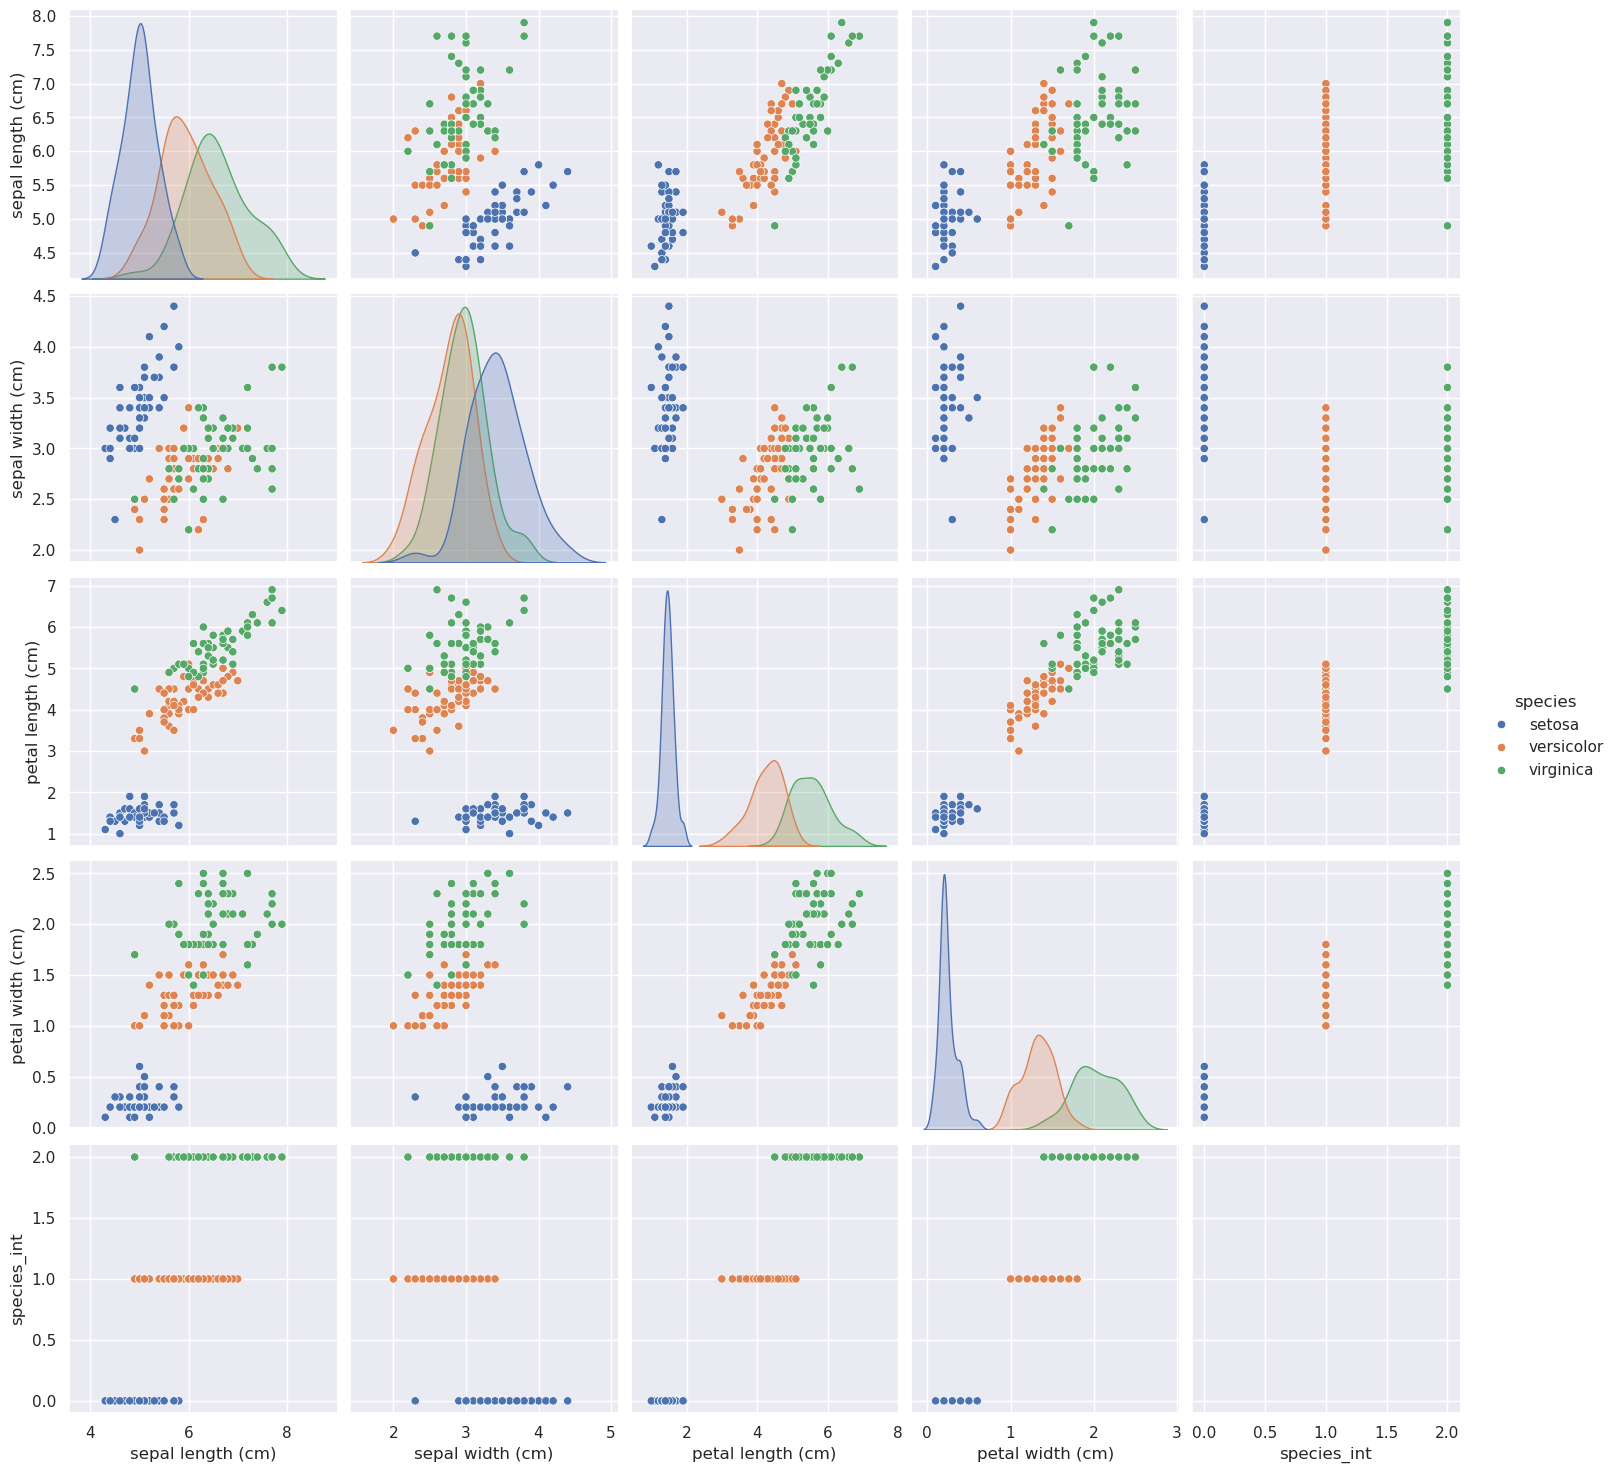

In [9]:
# JUST RUN THIS CELL :)
p = sns.pairplot(iris_full, hue="species", height=3)
plt.show()

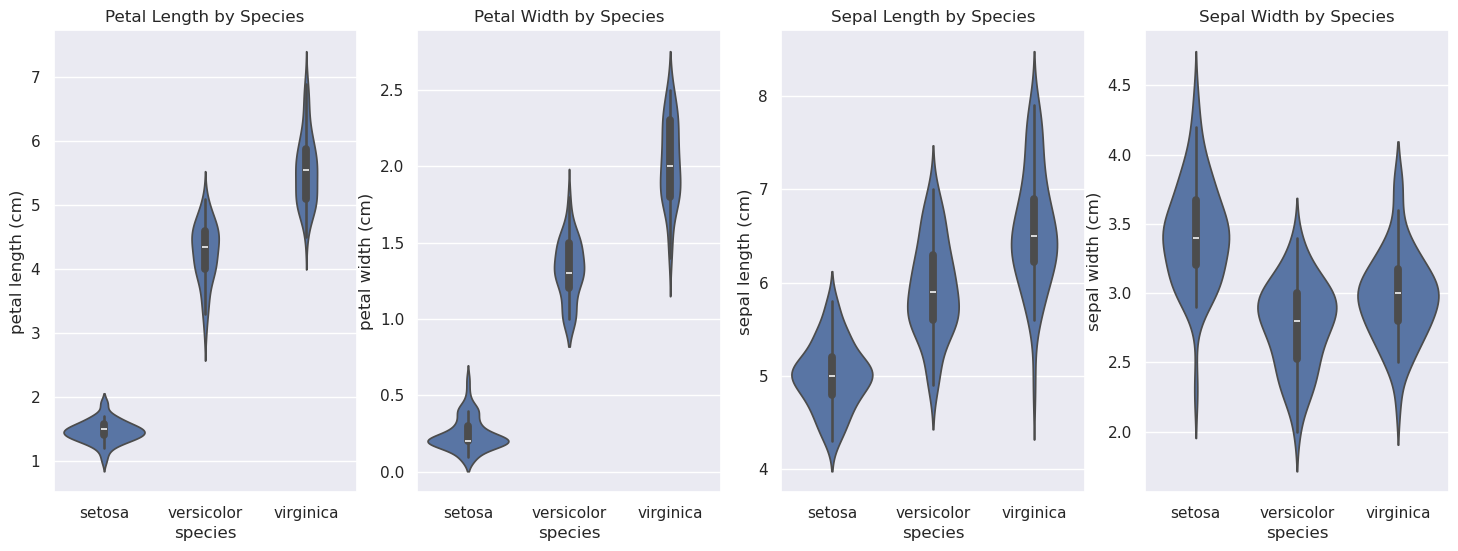

In [10]:
# JUST RUN THIS CELL :)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Violin plot for Petal Length
sns.violinplot(x="species", y="petal length (cm)", data=iris_full, ax=axes[0])
axes[0].set_title("Petal Length by Species")

# Violin plot for Petal Width
sns.violinplot(x="species", y="petal width (cm)", data=iris_full, ax=axes[1])
axes[1].set_title("Petal Width by Species")

# Violin plot for Sepal Width
sns.violinplot(x="species", y="sepal length (cm)", data=iris_full, ax=axes[2])
axes[2].set_title("Sepal Length by Species")

# Violin plot for Sepal Width
sns.violinplot(x="species", y="sepal width (cm)", data=iris_full, ax=axes[3])
axes[3].set_title("Sepal Width by Species")

plt.show()

<font color = #d14d0f>**QUESTION 1B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Now you will plot all flowers in the iris dataset in a simple scatterplot according to their petal length and petal widths. Plot the petal lengths on the x-axis. Assign the data points for each species to a different color. Hint: Use a single seaborn method, rather than calling matplotlib methods multiple times. Make sure all labels are clear and that you include a title.

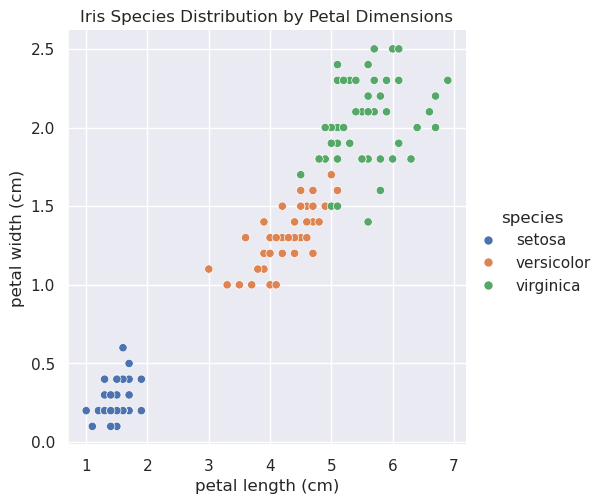

In [11]:
# YOUR CODE HERE
sns.relplot(data=iris_full, kind="scatter", x="petal length (cm)", y="petal width (cm)", hue="species")
plt.title("Iris Species Distribution by Petal Dimensions")
plt.show()

You should see that flowers with smaller petal width and length are easily identifiable as the setosa species. In contrast, determining whether a flower is versicolor or virginica is a harder task as the data points are not as easily separable.

<font color = #d14d0f>**QUESTION 1C**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Carefully examine the distribution plots above comparing the features across the three Iris species (Setosa, Versicolor, Virginica). Each plot displays how these features vary within and between species.

Using your observations, describe how well-separated the species appear to be for each feature. Which feature shows the clearest distinction among species, and which shows the most overlap? Consider how this would affect your ability to classify a new, unlabeled flower based on these features.

If you were tasked with predicting the species of a flower using only two features, which would you choose and why? Support your reasoning with specific visual patterns from the plots, and reflect on how similarity or overlap in feature values could influence how easily or accurately new data points might be categorized.



ANSWER: Using Petal Length and Petal Width allows for a clear decision boundary. For a new, unlabeled flower, if its petal length is under 2 cm, we can categorize it as Setosa with high confidence. If it is larger, the specific ratio of length to width in that upper-right cluster provides the best statistical chance of correctly distinguishing between Versicolor and Virginica, but due to the overlap, it wouldn't be as accurate. We'd need a better means of diffrentiation to be as confident.

---
---
### Unsupervised Machine Learning

There are two types of machine learning: supervised and unsupervised. We will start by looking at unsupervised machine learning. 

Unsupervised machine learning is used to uncover inherent structures or relationships within unlabeled data. The primary objective of unsupervised learning is to explore and uncover hidden patterns or structures within the data. This could involve tasks such as clustering similar data points together, reducing the dimensionality of the dataset while preserving essential information, or detecting anomalies or outliers. In unsupervised machine learning, there are no explicit target variables or class labels to guide the learning process. Instead, the algorithm aims to identify inherent patterns, structures, or relationships within the data without external guidance.

Clustering is a fundamental technique in unsupervised machine learning that involves grouping similar data points together based on certain features or characteristics, without prior knowledge of class labels. The goal of clustering is to partition a dataset into clusters, where data points within the same cluster are more similar to each other than they are to data points in other clusters. Various algorithms, such as K-means, hierarchical clustering, and DBSCAN, are employed to achieve this task, each with its own approach to defining similarity and partitioning the data. Clustering finds wide application across diverse domains, including social network analysis, customer segmentation, and image processing, where it is used to discover underlying structures, identify patterns, and gain insights from large and complex datasets.

In the realm of biology, where the complexity of biological systems often surpasses our comprehension, unsupervised machine learning emerges as a powerful tool for unraveling relationships within vast datasets without explicit guidance or labeled examples. In this lab, we will be using the K-means clustering methods with [`sklearn`](https://scikit-learn.org/) to look at patterns in our iris data set. 

### K-means Clustering Algorithm 
K-means is an algorithm used to group data into k clusters. It works by trying to minimize the distance between data points and the center of the cluster (aka the centroid) they belong to.

**Scaling features**

k-Means clustering relies on distance calculations — typically Euclidean distance — to assign points to the nearest cluster centroid. While our features are not on different scales, this can become a problem if they are. The algorithm will end up giving more weight to features with larger ranges, which can distort the clustering results. Sklearn has a tool called `StandardScaler` which standardizes features by centering them at zero and scaling to unit variance. The standard score of a sample x is calculated as follows: 

$$z = \frac{(x - u)}{s}$$

- $z$ is the standard score (also called a z-score)
- $x$ is the original value of the feature for a particular sample
- $u$ is the mean of the training samples
- $s$ is the standard deviation of the training samples

Below, we show you how to use `StandardScaler` from `sklearn.preprocessing` to scale the numeric features of the Iris dataset. We store the scaled data in a new variable called **scaled_data**.

In [12]:
# JUST RUN THIS CELL :)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(iris_features)
scaled_data[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

<font color = #d14d0f>**QUESTION 2A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

A characteristic of the k-means method is that you must choose the number of clusters in advance. We know that there are actually 3 species of flowers, so 3 would be a good choice of k for this dataset. But, what if we didn’t know the number of flower species? For multidimensional data this can be difficult to figure out.  

Try running k-means on our dataset with a K of 6. Use the `KMeans` class from `scikit-learn` to create a model that groups the iris data into the 6 clusters. Fit the model to
your scaled dataset to learn the cluster centers and assign each point to a cluster.  

We do this step for you, but please follow along with the description.

To do this, you first need to create a `kmeans` object, for which we’ve provided the relevant code line. We use the parameter `init=k-means++`, which is an efficient way to pick initial points for the centroids; after first picking one at random, then selecting the next ones with higher probability given to points that are farther away from existing centroids — helping to spread them out for better clustering. We also tell the algorithm to run multiple times and select the best performing model using `n_init=10`. We’ve chosen `random_state=42` so that your results will be deterministic; otherwise there is randomness in the process. 

After setting up the object, run `kmeans.fit` on your scaled data.

In [13]:
# JUST RUN THIS CELL :)
kmeans = KMeans(n_clusters=6, init = 'k-means++', random_state=42, n_init = 10)
kmeans.fit(scaled_data)

,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


<font color = #d14d0f>**QUESTION 2B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Now we’ll look to see what these clusters look like using just 2 of the features.  Once you've fitted the K-Means model to your scaled iris data, each data point has been assigned to a cluster based on its similarity to others. These clusters are stored in `kmeans.labels_`.

Make a scatterplot like the one in question 1C, but use the scaled petal width and length and color according to the cluster labels. To accomplish this easily, consider making a new dataframe out of `scaled_data` and the cluster labels that looks similar to the `iris_full` dataframe. The columns should be the different iris features plus one for assigned cluster.

Looking at the data, does 6 seem like a good number of clusters?

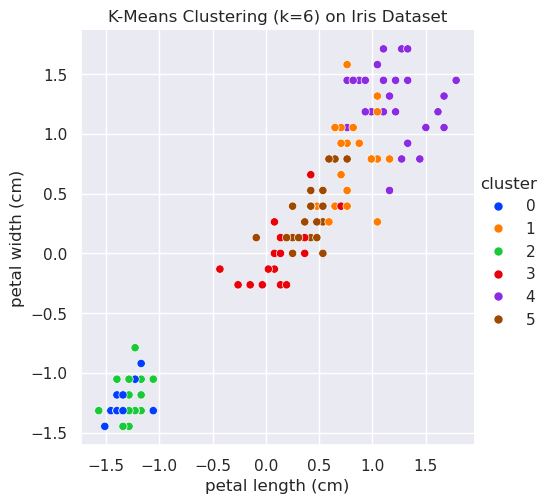

In [14]:
# Create a new dataframe from the scaled data
# We use iris_features.columns to keep the original measurement names
scaled_df = pd.DataFrame(scaled_data, columns=iris_features.columns)

# Add the cluster labels assigned by K-Means
scaled_df["cluster"] = kmeans.labels_

# Plot using scaled petal width and length
sns.relplot(data=scaled_df, x="petal length (cm)", y="petal width (cm)", hue="cluster", palette="bright")
plt.title("K-Means Clustering (k=6) on Iris Dataset")
plt.show()

ANSWER: No, 6 clusters does not seem like an ideal choice for this dataset due to over-segmentation and a lack of clear boundaries. We know data fits into 3 categories, so there isn't a reason for 6 clusters. Furthermore, the clusters lack clear boundaries whereby we can diffrentiate them from one another

***The Elbow Method***

To help make this decision on what K should be, we use a visual technique called the Elbow Method: 
🔗 [The Elbow Method - Medium article](https://medium.com/@zalarushirajsinh07/the-elbow-method-finding-the-optimal-number-of-clusters-d297f5aeb189)

The Elbow Method works by calculating something called the **Within-Cluster Sum of Squares (WCSS)** for a range of K values.  

WCSS measures the total squared distance between each point and the centroid of its assigned cluster.

The formula is:

$$
\text{WCSS} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \| x_i - \mu_j \|^2
$$

The ideal number of clusters is a balance between simplicity and performance. The WCSS (also referred to as **inertia** in `scikit-learn`) always decreases as K increases - you generally have more compact groups with more clusters, but there’s a point where adding more clusters doesn’t improve things much. This point is also called the elbow in our curve where increasing the k value doesn't necessarily decrease our inertia.

<font color = #d14d0f>**QUESTION 2C**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Write a for loop to iterate a list called **inertia** of WCSS values for different k values from 1 (just one big cluster) to 10.  You do this by running `kmeans.fit` repeatedly on the scaled data for each k, and then looking at the `kmeans.inertia_` for each k and saving to the inertia list.  So, the first element of inertia is the WCSS for k=1, and the 10th element is for k=10.

In [15]:
inertia = []

# Loop through k values from 1 to 10
for i in range(1, 11):
    # Initialize K-Means with current k
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    
    # Fit the model to the scaled data
    kmeans.fit(scaled_data)
    
    # Save the WCSS (inertia) to our list
    inertia.append(kmeans.inertia_)

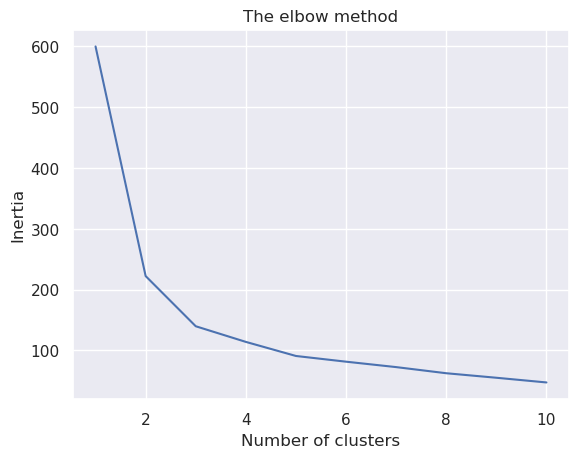

In [16]:
# JUST RUN THIS CELL :)
# This cell plots the inertias for different k clusters
plt.plot(range(1, 11), inertia)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia') #within cluster sum of squares
plt.show()

<font color = #d14d0f>**QUESTION 2D**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Where does the elbow appear to be to you?  Does this agree with your intuition?

ANSWER: It is at 2-3 clusters, and this agrees with the intuition to pick 3 clusters due to there being 3 species.

Now that you've scaled the features and explored the Elbow Method to choose an appropriate number of clusters, it's time to apply and use the KMeans class from sklearn to create a model that groups the scaled iris data into the appropriate number of clusters.

<font color = #d14d0f>**QUESTION 2E**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Fit a new `kmeans` model on the scaled data using the number of clusters chosen using the Elbow method.

In [17]:
# YOUR CODE HERE
# Initialize the model with the optimal k=3
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

# Fit the model to the scaled data
kmeans.fit(scaled_data)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


For ease of future use, we are adding the cluster assignments to the original unscaled `iris_full` DataFrame as a new column called `cluster`. We do this step for you. After fitting the K-Means model to the scaled data. This will allow us to analyze and interpret the clustering results in the context of the original feature values, facilitating meaningful insights and comparisons.

In [18]:
# JUST RUN THIS CELL :)
iris_full['cluster'] = kmeans.labels_

# Take a look at what the original dataframe looks like now
iris_full

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_int,cluster
0,5.1,3.5,1.4,0.2,setosa,0,1
1,4.9,3.0,1.4,0.2,setosa,0,1
2,4.7,3.2,1.3,0.2,setosa,0,1
3,4.6,3.1,1.5,0.2,setosa,0,1
4,5.0,3.6,1.4,0.2,setosa,0,1
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,2
146,6.3,2.5,5.0,1.9,virginica,2,0
147,6.5,3.0,5.2,2.0,virginica,2,2
148,6.2,3.4,5.4,2.3,virginica,2,2


## PCA, and Follow-up Analysis

Dimensionality reduction is a crucial technique in data analysis, particularly in the context of high-dimensional datasets where the number of features or variables is large. The primary goal of dimensionality reduction is to reduce the number of input variables while preserving as much relevant information as possible. This process helps alleviate the curse of dimensionality, where high-dimensional data can lead to increased computational complexity, overfitting, and difficulties in visualization and interpretation. Principal Component Analysis (PCA) is one of the most widely used dimensionality reduction techniques, which identifies the directions of maximum variance in the data and projects it onto a lower-dimensional subspace while retaining most of the variance. Depending on who you ask, PCA itself can be considered an unsupervised machine learning algorithm (although this becomes a philosophial debate)

[You can read more about PCA here](https://www.geeksforgeeks.org/principal-component-analysis-pca/).

<font color = #d14d0f>**QUESTION 2F**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

To better visualize the structure of the Iris dataset, we can reduce its dimensionality to two principal components using PCA. This enables the creation of 2D plots that reveal patterns and relationships within the data.

Begin by initializing PCA with a target dimensionality of two. To accomplish this, we use the `PCA` utility from `sklearn.decomposition`. Add the two principal components to the `iris_full` dataset as columns

**Reference**: [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)


In [19]:
# YOUR CODE HERE
# Initialize PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2)

# Fit and transform the scaled data
pca_data = pca.fit_transform(scaled_data)

# Add the two principal components to the iris_full dataframe
# pca_data[:, 0] gets the first column (PC1), pca_data[:, 1] gets the second (PC2)
iris_full['pca1'] = pca_data[:, 0]
iris_full['pca2'] = pca_data[:, 1]

<font color = #d14d0f>**QUESTION 2G**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

The plot generated by the code below should showcase a side-by-side comparison of the Iris dataset, displaying both the K-Means clustering results and the actual species classifications after reducing the dataset's dimensions using PCA. Set the hue to appropriately accomplish this task. Then examine these plots side by side, and evaluate the effectiveness of the K-Means clustering algorithm in identifying the inherent groupings within the Iris dataset and how these groupings correspond to the actual species classifications.

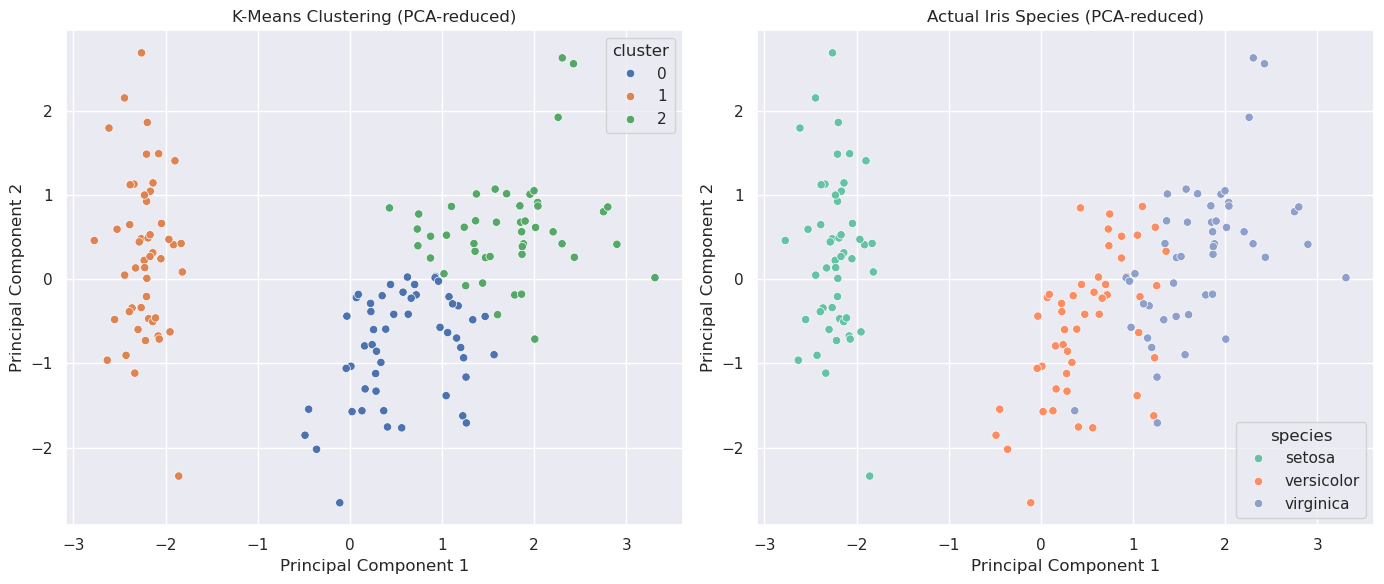

In [20]:
# Create the figure and a row of 2 subplots (axes)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Left plot: K-Means Clusters
sns.scatterplot(data=iris_full, x='pca1', y='pca2', hue='cluster', palette='deep', ax=axes[0])
axes[0].set_title('K-Means Clustering (PCA-reduced)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# # Right plot: Actual Species
sns.scatterplot(data=iris_full, x='pca1', y='pca2', hue='species', palette='Set2', ax=axes[1])
axes[1].set_title('Actual Iris Species (PCA-reduced)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# # Clean up layout
plt.tight_layout()
plt.show()

ANSWER: It is accurate for identifying Setosa, but struggles with the overlap between Versicolor and Virginica.

<font color = #d14d0f>**QUESTION 2H**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

In clustering tasks where ground truth labels are available, like our Iris data set, a confusion matrix helps assess how well the K-Means algorithm's clusters align with actual categories, and evaluate the homogeneity of each cluster. Fill in the parameters for the matrix accordingly. Then asesses whether the K-Means clusters align well with the true species groups overall? Justify your answer using the values in the matrix.

***NOTE:*** Remember that the cluster labels are arbitrary, since this is an unsupervised task. Therefore, cluster 0 may not necessarily correspond to class 0 (setosa)

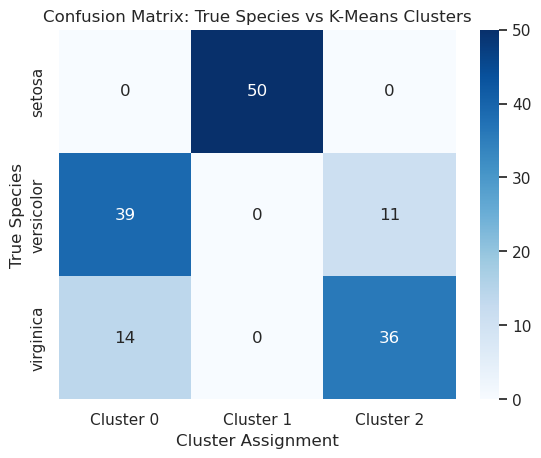

In [21]:
# # YOUR CODE HERE
# # Make confusion matrix
cm = confusion_matrix(iris_classes_int, kmeans.labels_)

# # Plot heatmap
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=[f"Cluster {i}" for i in range(3)],
            yticklabels=iris_class_names)
plt.xlabel("Cluster Assignment")
plt.ylabel("True Species")
plt.title("Confusion Matrix: True Species vs K-Means Clusters")
plt.show()

ANSWER: The K-means Clusters for Setosa is perfect, but there is substantial overlap between Versicolor and Virginica, although the substantial majority in both is still accurate.

---
---
## Supervised Classification Models
Previously we used unsupervised learning deals which deals with unlabeled data, where the algorithm aims to identify patterns, relationships, or groupings within the dataset without predefined output labels. In supervised learning, the algorithm is trained on a labeled dataset, where each input is associated with a corresponding output. The model learns to map inputs to outputs, allowing it to make predictions on new, unseen data. 

Classification methods are a component of supervised machine learning as they provide a framework for organizing and categorizing data into distinct classes or groups. The need for classification arises from the vast amount of information available in different domains, such as image recognition, spam detection, medical diagnosis, and financial fraud detection. By employing classification algorithms, machines can effectively assign new, unseen data points to predefined categories, facilitating decision-making processes and automating tasks that would be impractical or time-consuming for humans to perform manually.In this assignment, we will be looking at K-Nearest Neighbors <br>

### K-Nearest Neighbors (KNN)

K-Nearest Neighbors is frequently used to solve classification and regression problems. Since we are not predicting a continuous numeric variable, we will be exclusively focusing on predicting class with this algorithm.

KNN is a very simple straightforward algorithm. It has a single training parameter, $k$. The training step simply consists of storing the values and labels for a selected set of training data. To label a new point, the distance (often the [Euclidean distance](https://builtin.com/articles/euclidean-distance)) is computed between the new point and all the points in the training dataset. The new point is assigned the label corresponding to the most common label among the $k$ closest training points. For example, if $k = 3$, and the closest 3 points to the new point are labeled $\{1, 1, 2\}$, the new point would be labeled $1$.

In this way, KNN involves making predictions based on the entire dataset rather than exclusively focusing on a specific learning model. In more technical terms, we would say it is a **"non-parametric"** or **"instance-based"** learning algorithm.

## Preparing Data for `scikit-learn`’s **K-Nearest Neighbors**

The model will use **features** to predict a **species**.  
To work with `scikit-learn`’s KNN implementation, set up your data as follows:

1. **Encode the class label**  
   *Represent each species with a numeric code (e.g., 0, 1, 2) instead of its name.*

2. **Separate predictors from the label**  
   *Place all feature columns in one array while keeping the class (species) column separate.*

3. **Create training and test splits**  
   *Split **both** the feature matrix and the class vector into training and test subsets.*

After these steps you will have **four** variables:

- `iris_class_train`  
- `iris_feature_train`  
- `iris_class_test`  
- `iris_feature_test`


One of the key components of model building is splitting our data into training and test sets. We use the training set to construct our model and then evaluate its performance on the test set. There are many ways to split into training and test sets, but our data are amenable to doing so in the most straightforward fashion. Fortunately, there's a `scikit-learn` function called `train_test_split` that will do everything for us. 

Set your paramters here to 75% training and 25% test, but note you can alter these paramters in the future on your own models. It is generally good practice to shuffle your data prior to the split, to prevent order-related biases and ensure that both subsets are representative of the overall dataset. `train_test_split` in `scikit-learn` shuffles the data by default. Here we used a fixed random state to have a deterministic result for evaluating student work.

<font color = #d14d0f>**QUESTION 3A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Use `train_test_split()` to split the features and class labels. (Hint: Use the integer class labels).

In [22]:
# Split the data into training (75%) and testing (25%) sets
# We use iris_features for X and iris_classes_int for y
iris_feature_train, iris_feature_test, iris_class_train, iris_class_test = train_test_split(iris_features, iris_classes_int, test_size=0.25,
random_state=41)

It's good practice to check the shape of your train and test sets after splitting to make sure the data was divided correctly and that all sets have the expected dimensions. This quick check helps confirm that nothing went wrong during the split and that your features and labels are properly aligned before training a model. Display the shape of your test and train data. 

In [23]:
# JUST RUN THIS CELL :)
print("iris_feature_train", iris_feature_train.shape)
print("iris_feature_test", iris_feature_test.shape)
print("iris_class_train", iris_class_train.shape)
print("iris_class_test", iris_class_test.shape)

iris_feature_train (112, 4)
iris_feature_test (38, 4)
iris_class_train (112,)
iris_class_test (38,)


<font color = #d14d0f>**QUESTION 3B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

We are ready to initiate our model. Set up the `KNeighborClassifier` into the variable `knn`. As a first pass, initiate k (`n_neighbors`) with 1. Next, fit the model on the training data (`iris_feature_train` and `iris_class_train`):

In [24]:
# YOUR CODE HERE
# Initialize the KNN classifier with n_neighbors=1
knn = KNeighborsClassifier(n_neighbors=1)

# Fit the model using the training features and training labels
knn.fit(iris_feature_train, iris_class_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<font color = #d14d0f>**QUESTION 3C**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Now that you've trained your KNN model on the training data, it's time to test how well it performs on the test set.

Use the `.predict()` method to generate predictions for the test features (`iris_feature_test`) and store the results in a variable called `class_pred`.

After that, display `class_pred` to see the predicted class labels for your test data.

In [25]:
# YOUR CODE HERE
# Generate predictions for the test set
class_pred = knn.predict(iris_feature_test)

# Display the predicted labels
class_pred

array([1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 0, 2, 1])

<font color = #d14d0f>**QUESTION 3D**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Now, let's check how well our model performs on the test data.

The **Mean Squared Error (MSE)** measures the average squared difference between the predicted and actual values. A lower MSE suggests better predictive performance. It's especially useful for understanding the scale of prediction error.

The **Accuracy** reports how often the model got the correct answer. A higher accuracy suggests better predictive performance. Here, we are reporting **multiclass classification accuracy**:  [Accuracy and precision (Wikipedia)](https://en.wikipedia.org/wiki/Accuracy_and_precision#In_multiclass_classification).

Then, determine the accuracy of your predictions:
- Use `scikit-learn`'s `mean_squared_error` function to calculate the MSE between `iris_class_test` and `class_pred`.
- Then, use `knn.score()` determine the accuracy of your predictions.

In [26]:
# # YOUR CODE HERE
# Calculate the Mean Squared Error
mse = mean_squared_error(iris_class_test, class_pred)

# Calculate the Accuracy Score 
# We test the model on the unseen test features and labels
accuracy = knn.score(iris_feature_test, iris_class_test)

# Print the results
print(f"MSE:\t\t {mse}")
print(f"accuracy:\t {accuracy}")

MSE:		 0.10526315789473684
accuracy:	 0.8947368421052632


### Choosing the Right k
In K-Nearest Neighbors, k is the number of closest data points the algorithm looks at to make a prediction. It is essentially a number that tells the algorithm how many nearby data points to consider when making a prediction. For example, if k = 3, the algorithm looks at the 3 closest data points to the new point and predicts the class that appears most often among those 3 neighbors. So, k controls how many neighbors influence the prediction.

Choosing k in k-Nearest Neighbors is about finding a balance between overfitting and underfitting. A small k can make the model too sensitive to noise, while a large k can make it too general. The best k is usually found by testing several values.

Different `k` values will produce different models with different accuracy scores. Let’s try to find the **most optimal `k` value** with the highest accuracy for our dataset. We will explore potential `k` values from **1 to 30**.

<font color = #d14d0f>**QUESTION 3E**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a `for` loop that iterates through `k` values from 1 to 30 and repeat all steps of implementing the k-nearest neighbors algorithm for each `k`. Calculate and record the accuracy score for each value of `k`. Then make a line plot of the error values.

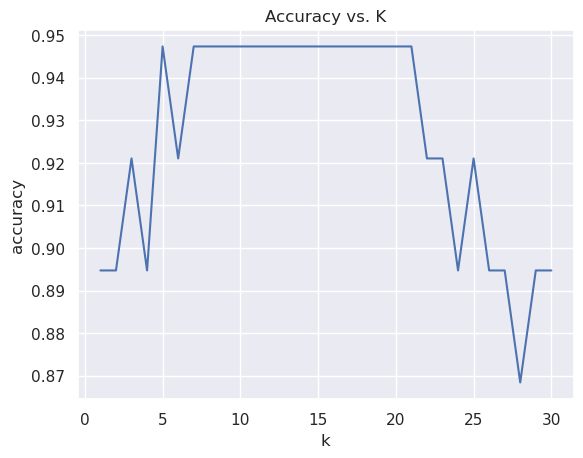

In [27]:
# # YOUR CODE HERE
accuracy_scores = []
k_values = list(range(1, 31))

for k in k_values:
    # Initialize the model with the current k
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Fit the model on training data
    knn.fit(iris_feature_train, iris_class_train)
    
    # Calculate accuracy on the test data
    accuracy = knn.score(iris_feature_test, iris_class_test)
    
    # Save the score
    accuracy_scores.append(accuracy)

# Plotting the results
sns.lineplot(x=k_values, y=accuracy_scores)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("Accuracy vs. K")
plt.show()

<font color = #d14d0f>**QUESTION 3F**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Proceed to select a k value that achieves balance between bias and variance discussed earlier. Then, create and train your k-NN model using that value, and store the result in the variable `knn_ideal`. After training, use the model to make predictions on your test set and store those predictions in the variable `class_pred`.

In [28]:
# YOUR CODE HERE
# 1. Initialize with your chosen ideal k (e.g., 10)
knn_ideal = KNeighborsClassifier(n_neighbors=10)

# 2. Fit the model on the training data
knn_ideal.fit(iris_feature_train, iris_class_train)

# 3. Make predictions on the test set
class_pred = knn_ideal.predict(iris_feature_test)

# 4. Display the predictions
class_pred

array([2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 0, 2, 1])

### Precision and Recall

Precision and recall are two important metrics used to evaluate the performance of a classification model.

- **Precision** measures how many of the predicted positive cases were actually correct, focusing on the model’s positive predictions.
- **Recall**, on the other hand, measures how many of the actual positive cases were successfully identified by the model, focusing on its ability to capture all relevant instances.

#### Formulas:

- **Precision** = $\frac{TP}{TP+FP}$ (True Positives divided by the sum of True Positives and False Positives)

- **Recall** = $\frac{TP}{TP+FN}$ (True Positives divided by the sum of True Positives and False Negatives)

<font color = #d14d0f>**QUESTION 3G**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

We will now evaluate how well our KNN model performs across the three Iris species.
- Generate a **classification report** and a **confusion matrix** using your test predictions (`class_pred`) and the true labels (`iris_class_test`).
- Use `classification_report()` and `confusion_matrix()` from `sklearn.metrics` to do this.
-  **Note:**  The classification report uses a metric called **F1**.  The F1 score is the **harmonic mean** of precision and recall, providing a single value that summarizes both by considering them symmetrically. Learn more here: [F1 Score (Wikipedia)](https://en.wikipedia.org/wiki/F-score). All metrics have limitations.  F1 can be particularly inappropriate for many problems in biology where datasets are **unbalanced** or where **high specificity** is required.  However, for this application, it is a reasonable metric to use.
  
Assess the results of the matrix and report. In your stament address the following
- What does the classification report tell you about the model's precision, recall, and F1-score for each of the three Iris species? Don't just cite values. Explain what this means 
- Are there any species the model struggles to classify accurately? What might explain this?
- What patterns do you observe in the **confusion matrix**? Are there particular species that are often confused with one another?
- Based on these results, would you consider this model reliable for distinguishing between all three Iris species? Why or why not?


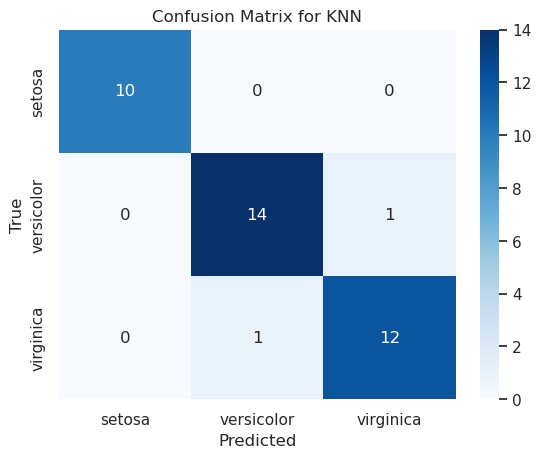

In [29]:
# Create the confusion matrix
cm = confusion_matrix(iris_class_test, class_pred)

# Plot the heatmap
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=iris_class_names,
            yticklabels=iris_class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for KNN")
plt.show()

In [30]:
# Print the classification report
print(classification_report(iris_class_test, class_pred, target_names=iris_class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.93      0.93      0.93        15
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



ANSWER: Precision is the accuracy of the model and recall is the model's ability to find all actual members of a species. The F1-score provides harmonic mean of both, and shows a high overall performance for each Iris species. The model is 100% accurate for setosa but there is a slight overlap between versicolor and virginica. This is due to the overlap in their petal length and width. The model is fairly reliable for identifying setosa, but there is slight inaccuracy in identifying versicolor vs virginica.

### Decision Tree Classification
Decision trees are another supervised non-parametric learning method. In this method, the model learns a set of simple rules to split the data into smaller and smaller buckets, until the buckets only contain samples corresponding to a single label. This can be thought of as building a tree of yes/no questions, where the answers to those questions determine the label of new samples.

<font color = #d14d0f>**QUESTION 4A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Initialize a `DecisionTreeClassifier`. Fit this model using the same training data you used for KNN (`iris_feature_train` and `iris_class_train`).

In [31]:
# YOUR CODE HERE
# Initialize the Decision Tree Classifier
# We use random_state=41 to match your previous train/test split
dt_model = DecisionTreeClassifier(random_state=41)

# Fit the model on the training data
dt_model.fit(iris_feature_train, iris_class_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,41
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


One of the advantages of using a decision tree is how easy it is to interpret what the algorithm is doing. The following code will visualize the decision tree you fit above:

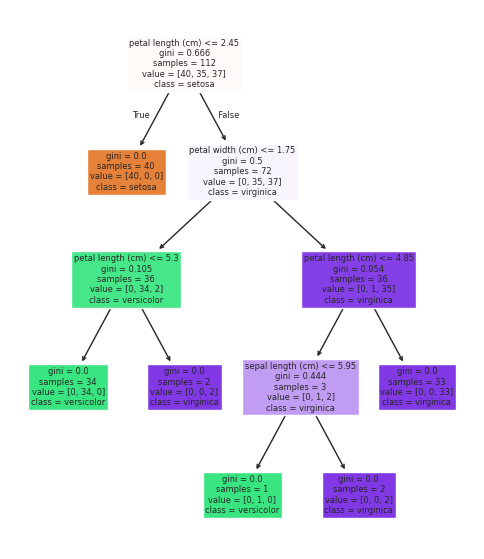

In [32]:
# JUST RUN THIS
species = iris_classes_str.unique()
plt.figure(figsize=(6, 7))
plot_tree(dt_model, filled=True, feature_names=iris_features.columns, class_names=iris_class_names)
plt.show()

Each box represents a node in the tree. The first line in each box shows the simple decision rule that is carried out at that node (some form of equality or inequality statement involving a single variable). The `samples` line shows the number of training samples at that node. The `value` line shows the distribution of class labels for the training samples at that node. The `class` line shows the label corresponding to the majority of the training samples at that node.

Notice that the traning samples in each of the the bottom nodes (the "leaves") all share the same label.

<font color = #d14d0f>**QUESTION 4B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Examine the structure of the tree pictured above. What does its structure suggest about the classes in this dataset? How does this observation compare with the structure of the PCA-reduced K-Means plot?

ANSWER: It suggests that Setosa is immediately identfiable, but there is much more decision making before a sample can be identified as Versicolor or Virginica. Both the Tree and PCA plot agree that Setosa is easily identified while diffrentiating Versicolor and Virginica is tougher

<font color = #d14d0f>**QUESTION 4C**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Use your trained decision tree model (dt_model) to predict the classes for your test features. Then, evaluate the model's performance by generating a Confusion Matrix and printing a classification report

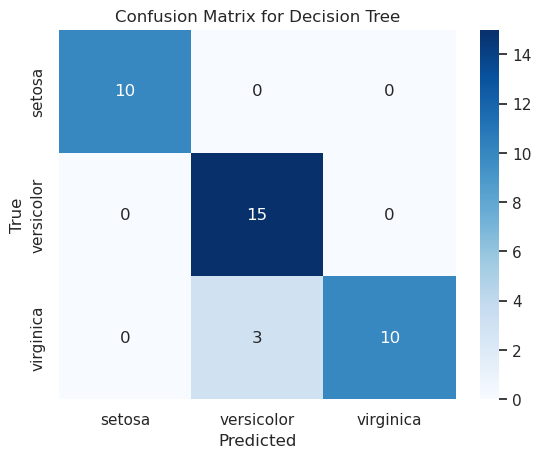

In [33]:
# YOUR CODE HERE
# 1. Generate predictions using the test features
class_pred = dt_model.predict(iris_feature_test)

# 2. Create the confusion matrix
cm = confusion_matrix(iris_class_test, class_pred)

# 3. Plot the heatmap for the Decision Tree
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=iris_class_names,
            yticklabels=iris_class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Decision Tree")
plt.show()

In [34]:
# 4. Print the classification report
print(classification_report(iris_class_test, class_pred, target_names=iris_class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.93        38
weighted avg       0.93      0.92      0.92        38



### Random Forest Classification

While they are simple and effective, decision trees have some major disadvantages. One problem is that they tend to overfit the training data, making them generalize poorly to new data without taking additional measures. Another issue is that they can be highly sensitive to small variations in the input data.

To address some of these problems, you can build multiple trees instead of relying on a single decision tree. A Random Forest classifier creates many trees, which "vote" on the final classification. This usually yields more accurate results.

To demonstrate this, we will use a new dataset. This digits dataset is a collection of tiny, grayscale images of handwritten numbers (0 through 9). Each image is actually an 8×8 grid of pixels (64 pixels total). As an example, here is one of the pictures of a zero:

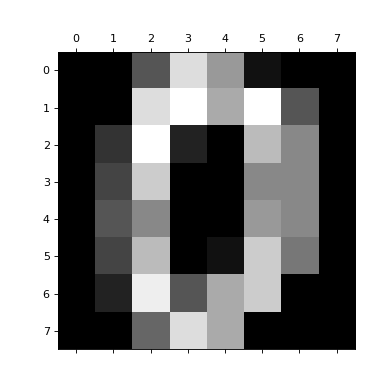

The classification task in question is to look at the 64 pixel values and guess the digit.

In [35]:
# JUST RUN THIS
digits_test_data = load_digits(as_frame=True)
digits_test_features = digits_test_data.data
digits_test_classes = digits_test_data.target

In [36]:
# JUST RUN THIS
digits_test_features.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [37]:
# JUST RUN THIS
digits_test_classes.value_counts().sort_index()

0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: target, dtype: int64

Just as before, we will create a train-test split.

In [38]:
# JUST RUN THIS
digits_feature_train, digits_feature_test, digits_class_train, digits_class_test = train_test_split(digits_test_features, digits_test_classes, test_size=0.25, random_state=41)

<font color = #d14d0f>**QUESTION 5A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Initialize a `DecisionTreeClassifier`. Fit this model using the split digits data (`digits_feature_train` and `digits_class_train`).

In [39]:
# YOUR CODE HERE
# Calculate and print the accuracy of the Decision Tree
tree_accuracy = dt_model.score(iris_feature_test, iris_class_test)

print(f"Decision Tree Accuracy: {tree_accuracy}")
print(f"KNN Accuracy:          {accuracy}") # Using the accuracy variable from your ideal KNN

Decision Tree Accuracy: 0.9210526315789473
KNN Accuracy:          0.8947368421052632


<font color = #d14d0f>**QUESTION 5B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Use your trained decision tree model (`dt_model`) to predict the classes for your test features. Then, evaluate the model's performance by generating a Confusion Matrix and printing a classification report

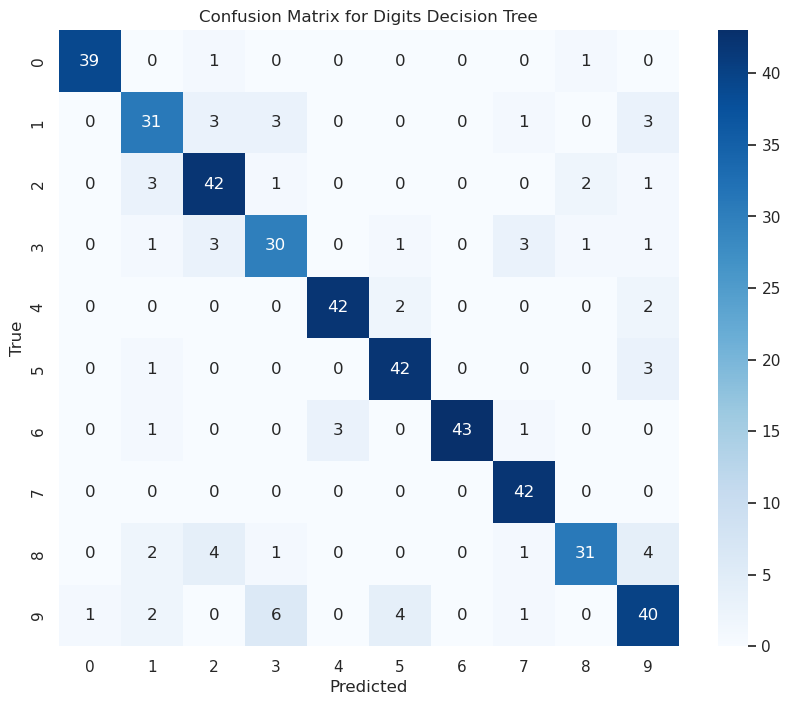

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.76      0.76      0.76        41
           2       0.79      0.86      0.82        49
           3       0.73      0.75      0.74        40
           4       0.93      0.91      0.92        46
           5       0.86      0.91      0.88        46
           6       1.00      0.90      0.95        48
           7       0.86      1.00      0.92        42
           8       0.89      0.72      0.79        43
           9       0.74      0.74      0.74        54

    accuracy                           0.85       450
   macro avg       0.85      0.85      0.85       450
weighted avg       0.85      0.85      0.85       450



In [40]:
# Initialize a new Decision Tree for the Digits data
dt_model = DecisionTreeClassifier(random_state=41)

# Fit the model using the digits training features and classes
dt_model.fit(digits_feature_train, digits_class_train)

digits_dt_class_pred = dt_model.predict(digits_feature_test)

# Create the confusion matrix
cm = confusion_matrix(digits_class_test, digits_dt_class_pred)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Digits Decision Tree")
plt.show()

# Print the classification report
print(classification_report(digits_class_test, digits_dt_class_pred))

In [41]:
# # YOUR CODE HERE
# 4. Print the detailed report
print(classification_report(digits_class_test, digits_dt_class_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.76      0.76      0.76        41
           2       0.79      0.86      0.82        49
           3       0.73      0.75      0.74        40
           4       0.93      0.91      0.92        46
           5       0.86      0.91      0.88        46
           6       1.00      0.90      0.95        48
           7       0.86      1.00      0.92        42
           8       0.89      0.72      0.79        43
           9       0.74      0.74      0.74        54

    accuracy                           0.85       450
   macro avg       0.85      0.85      0.85       450
weighted avg       0.85      0.85      0.85       450



<font color = #d14d0f>**QUESTION 5C**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Describe the performance of this classifier.

ANSWER: It performs well, albeit with worse accuracy. The diagonal is still strong, but there are noticeable areas of confusion.

<font color = #d14d0f>**QUESTION 5D**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Initialize a RandomForestClassifier with 100 estimators (`n_estimators=100`) and a random_state of 42. Fit this model using the training features and training classes you prepared in the previous step (e.g., `digits_feature_train` and `digits_class_train`).

In [42]:
# YOUR CODE HERE
# 1. Initialize the Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the model on the digits training data
rf_model.fit(digits_feature_train, digits_class_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<font color = #d14d0f>**QUESTION 5E**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Evaluate the performance of this random forest classifier using a confusion matrix, as you've done multiple times previously in this lab.

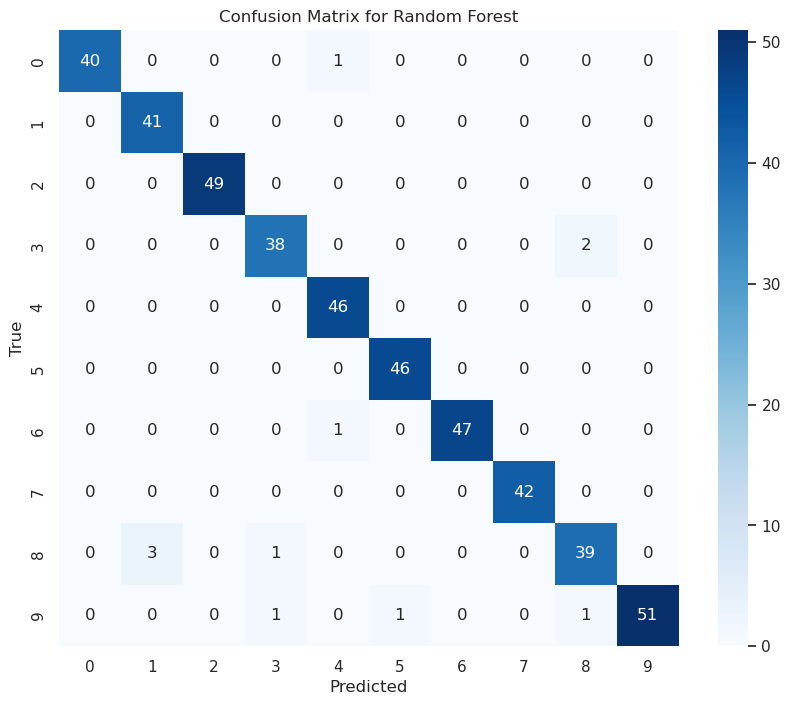

In [43]:
# YOUR CODE HERE
# 1. Generate predictions
digits_rf_class_pred = rf_model.predict(digits_feature_test)

# 2. Create confusion matrix
cm = confusion_matrix(digits_class_test, digits_rf_class_pred)

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Random Forest")
plt.show()

<font color = #d14d0f>**QUESTION 5F:**</font> <font color = #0fd12c>**AI PERMITTED**</font>

Generate a classification_report for the Random Forest model. How does its performance compare to the single Decision Tree model? Can you think of any downsides to using Random Forests instead of Decision Trees?

In [44]:
# YOUR CODE HERE
# Generate the classification report using the true labels and RF predictions
print(classification_report(digits_class_test, digits_rf_class_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        41
           1       0.93      1.00      0.96        41
           2       1.00      1.00      1.00        49
           3       0.95      0.95      0.95        40
           4       0.96      1.00      0.98        46
           5       0.98      1.00      0.99        46
           6       1.00      0.98      0.99        48
           7       1.00      1.00      1.00        42
           8       0.93      0.91      0.92        43
           9       1.00      0.94      0.97        54

    accuracy                           0.98       450
   macro avg       0.97      0.98      0.97       450
weighted avg       0.98      0.98      0.98       450



ANSWER: The Random Forestis certainly much more accurate. However, the Decision Tree is significantly easier to read, and is a much more digestible means of data presentation; we do still have the confusion matrix though. 

### ROC curves
ROC stands for Receiver Operating Characteristic, and is a useful way to visualize the performance of a model. An ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at a set of different classification thresholds, using the training data. At each threshold, a sample is only counted as a True Positive if the following conditions are true:

* The probability that this sample has a given label is over the threshold
* The label assigned to that sample is correct

An ROC curve shows the tradeoff between the *sensitivity* and *specificity* of a model. For a bad model which does no better than random chance, $TPR=FPR$, meaning that the model has a 50% chance of getting the answer right. For a good model, $TPR \geq FPR$. ROC curves are usually summarized using the area under the curve (AUC). For the worst possible model, one which selects labels entirely at random, $AUC=0.5$. For a perfect model, $AUC=1.0$. 

In our case, the ROC curve visualizes how well our model distinguishes between the different digits. Standard ROC is designed for binary classification  so we will take a "one vs. rest" approach, where asigning a label to our target species is a "positive" result and any other species is a "negative" result.

We can use the sklearn method `label_binarize` to implement the one vs. rest approach, using the test labels from the earlier call to `train_test_split`.

In [45]:
# JUST RUN THIS
print(digits_class_test.head())

1020    9
1494    0
445     3
1562    9
1553    8
Name: target, dtype: int64


In [46]:
# JUST RUN THIS
true_labels_binarized = label_binarize(digits_class_test, classes=dt_model.classes_)
print(true_labels_binarized.shape)
print(true_labels_binarized[0:5])

(450, 10)
[[0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0]]


`true_labels_binarized` now contains what is called a ***one-hot encoding*** of the class labels for the test set.

Next, we can predict the probability that each observation in the test set is in each of the classes, using `dt_model.predict_proba`. Note that this output is the same shape as `true_labels_binarized`.

In [47]:
# JUST RUN THIS
dt_probabilities = dt_model.predict_proba(digits_feature_test)
print(dt_probabilities.shape)
print(dt_probabilities[0:5])

(450, 10)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


<font color = #d14d0f>**QUESTION 6A**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Plot ROC curves for the prediction results from the `dt_model`. There should be one curve for each digit, calculated in a one-vs.-rest manner, all on the same plot. Make sure that the curves and axes are labeled clearly and appropriately. **(Hint: you want to include every row, but only one column)**

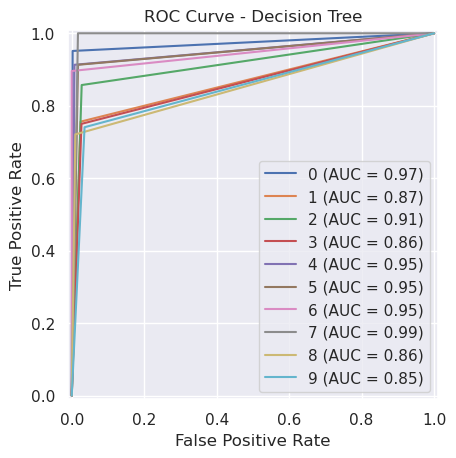

In [48]:
# YOUR CODE HERE
plt.figure()

# Loop through each class (digit 0 through 9)
for digit in range(dt_model.n_classes_):
    # We use all rows (:) for the specific digit's column
    RocCurveDisplay.from_predictions(
        true_labels_binarized[:, digit], 
        dt_probabilities[:, digit],
        ax=plt.gca(), 
        name=str(digit)
    )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.show()

<font color = #d14d0f>**QUESTION 6B**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create the same plot for the `rf_model`. The binarized true labels are the same. You will have to calculate the probability assignments for the `rf_model`. As before, make sure that the curves and axes are labeled clearly and appropriately.

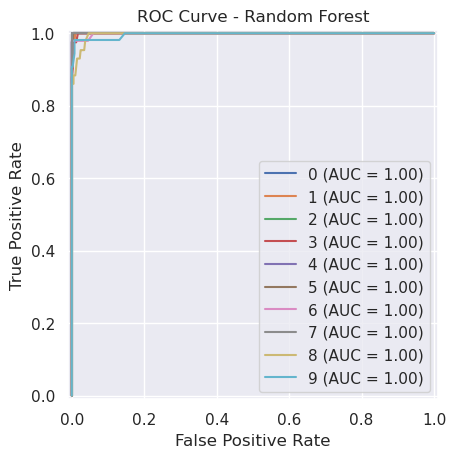

In [49]:
# YOUR CODE HERE
# 1. Calculate the probability assignments for the rf_model
rf_probabilities = rf_model.predict_proba(digits_feature_test)

# 2. Create the plot
plt.figure()

# Loop through each class (digit 0 through 9)
for digit in range(rf_model.n_classes_):
    # Use binarized true labels and RF probabilities for the specific digit
    RocCurveDisplay.from_predictions(
        true_labels_binarized[:, digit], 
        rf_probabilities[:, digit],
        ax=plt.gca(), 
        name=str(digit)
    )

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.show()

<font color = #d14d0f>**QUESTION 6C:**</font> <font color = #0fd12c>**AI PERMITTED**</font>

Answer the following:

## 1. **What does it mean for a curve to be in the far top-left corner in terms of True Positives and False Positives?** 

*Top Left means an ideal, or nigh perfect test/classifier, high true positives and low false positives.*

2. **If you were a biologist, how much could you trust this model to identify a flower of each species?**

*You could trust it to identify Setosa very well, but would have to double check Versicolor vs Virginica.*

3. **If one of your species' curves followed a diagonal line exactly, where y = x, what would that tell you about your model’s ability to learn from the features provided?**

*It would mean that the model is functionally guessing at random, and cannot truly classify anything with any amount of accuracy.*

4. **What are the differences between the two ROC curves (random forest vs. decision tree)?**

*The curve for the Random Forest is much smoother, which results in a much higher AUC.*

5. **What does this mean in terms of evaluating the classifiers?**

*The Random Forest is much more accurate. It is however tougher to visually represent and understand the data, so a confusion matrix is quite helpful. In addition, the Random Forest demands significantly more compute power, so as the size of the dataset scales, perhaps for models that don't demand as much accuracy, a decision tree may be sufficient.*

---
---
# You've finished!
Remember to submit a PDF and IPYNB on Gradescope.